# Paquetes

In [2]:
using PhysicalConstants
using PhysicalConstants.CODATA2022: ħ, m_e, c_0
using Unitful
using Plots

# Funciones

In [3]:
function Kronig_Penney(E, ω, b, V₀; m_eff = 0.067, normalizado = false)
    
    a = ω + b
    
    # estas dos variables las añado para que el coseno de k₁ y k₂ no haga overflow
    mₑc² = ustrip(uconvert(u"eV", m_e*c_0^2))                 # en EV
    ħc = ustrip(uconvert(u"eV*nm", ħ*c_0))                    # en eV nm

    k₁ = @. sqrt(2 * m_eff * mₑc² * E) / ħc                   # en nm⁻¹
    k₂ = @. sqrt(Complex(2 * m_eff * mₑc² * (E - V₀))) / ħc   # en nm⁻¹
    
    # Valor de cos(ka), con esto vemos las bandas imponiendo que f este entre -1 y +1
    f = @. cos(k₁*ω)*cos(k₂*b) - ((k₁^2 + k₂^2) / (2 * k₁ * k₂)) * sin(k₁*ω)*sin(k₂*b)
    
    banda = real.(f)
    
    k_eff, E_eff = Calcular_k(E, banda, a, normalizado)
    
    return banda, k_eff, E_eff
end



function Calcular_k(E, band, a, normalizar)
    
    Es = []
    ks = []
    
    for i in 1:length(band)
        if (abs(band[i]) <= 1.0)
            push!(Es, E[i])
            if normalizar
                push!(ks, acos(band[i])/π)    # en unidades de π/a
            else
                push!(ks, acos(band[i])/a)    # k en nm⁻¹
            end
        end
    end
    
    return ks, Es
end
        

Calcular_k (generic function with 1 method)

# Datos

In [7]:
Energy = 1.45:0.0001:1.60
Barrier_Potential = 0.4
Barrier_width = 2.0
Well_width = 6.0
banda, k_bandas, E_bandas = Kronig_Penney(Energy,Well_width,Barrier_width,Barrier_Potential, normalizado = true)

([0.9652253182911448, 0.9653481974022269, 0.9654708663684278, 0.9655933251886833, 0.9657155738619742, 0.9658376123873234, 0.9659594407638016, 0.9660810589905212, 0.9662024670666393, 0.9663236649913575  …  0.9227337512456008, 0.9225639054511879, 0.9223938899094831, 0.9222237046705436, 0.9220533497844472, 0.9218828253012958, 0.9217121312712157, 0.9215412677443551, 0.9213702347708858, 0.9211990324010042], Any[0.0841905498769892, 0.08404079954167445, 0.08389104491368984, 0.08374128593861273, 0.08359152256163606, 0.08344175472756785, 0.08329198238082158, 0.08314220546541955, 0.08299242392498582, 0.08284263770274237  …  0.1259496239405869, 0.12608981539997255, 0.12622999927280454, 0.12637017556893368, 0.12651034429817093, 0.12665050547028484, 0.12679065909500148, 0.1269308051820064, 0.12707094374094402, 0.1272110747814165], Any[1.45, 1.4501, 1.4502, 1.4503, 1.4504, 1.4505, 1.4506, 1.4507, 1.4508, 1.4509  …  1.5991, 1.5992, 1.5993, 1.5994, 1.5995, 1.5996, 1.5997, 1.5998, 1.5999, 1.6])

# Gráficos

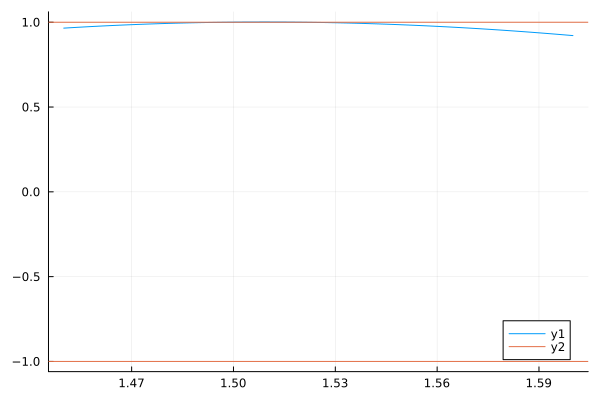

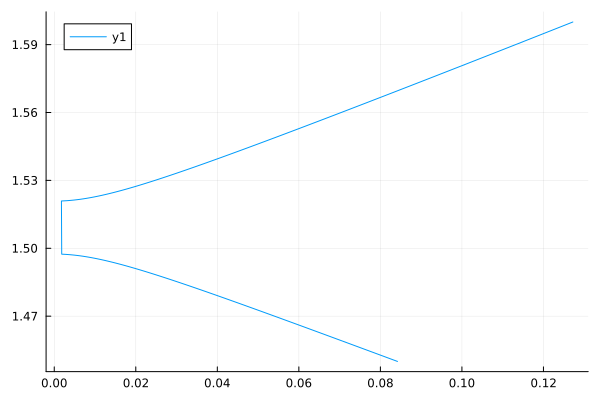

In [8]:
p1 = plot(Energy, banda)
hline!([1.0, -1.0])
p2 = plot(k_bandas,E_bandas)

display(p1)
display(p2)